# 1. Header & Introduction (Text Cell)

# Task 3: Loan Eligibility Prediction

Objective To build a Machine Learning model that predicts whether a loan application will be approved based on applicant details like income, credit history, and education.

* Algorithm Used: Random Forest Classifier (Ensemble Learning)

2. Setup & Data Loading (code cell)

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Loading the 'Raw Material'
url = "https://raw.githubusercontent.com/subashgandyer/datasets/master/loan_prediction.csv"
df = pd.read_csv(url)

print("Setup Complete! We have the data.")

Setup Complete! We have the data.


3. 3. Data Preprocessing (Text Cell)
* Data Cleaning & Encoding
In this step, we handle missing values by filling them with the mean (for numbers) or mode (for categories). We also use LabelEncoder to convert text data into a numerical format that the model can process.

4. Cleaning & Encoding (Code Cell)

In [16]:
# Filling missing values
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].mean())
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

# Encoding categorical text to numbers
le = LabelEncoder()
for col in ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']:
    df[col] = le.fit_transform(df[col].astype(str))

print("Data Preprocessing Complete.")

Data Preprocessing Complete.


5. Feature Selection (Code Cell)

In [17]:
# We only drop columns if they actually exist in the dataframe
cols_to_drop = ['Loan_ID', 'Loan_Status']
X = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# The target 'y' is our Loan_Status
y = df['Loan_Status']

# Splitting into 80% Training and 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Step 5 Complete: Features selected and data split safely!")

Step 5 Complete: Features selected and data split safely!


6. Model Training & Evaluation (Code Cell)

In [18]:
from sklearn.metrics import classification_report, accuracy_score
# Initializing Random Forest with 100 trees
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Making Predictions on the test set
y_pred = model.predict(X_test)

# Displaying Results
print(f"Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("-" * 30)
print("Classification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 76.42%
------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.42      0.55        43
           1       0.75      0.95      0.84        80

    accuracy                           0.76       123
   macro avg       0.79      0.68      0.70       123
weighted avg       0.78      0.76      0.74       123



7. Visualization (Code Cell)

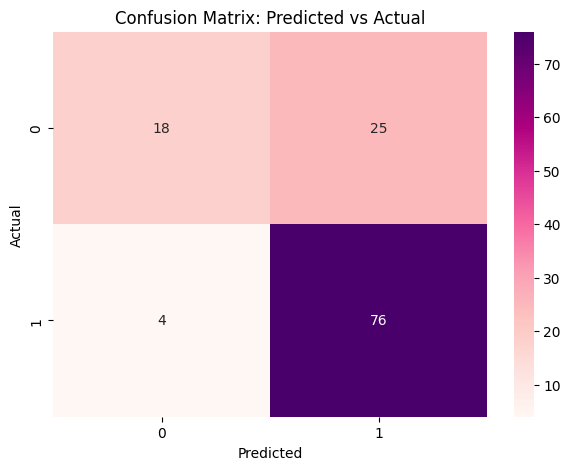

In [19]:
plt.figure(figsize=(7,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap='RdPu', fmt='g')
plt.title('Confusion Matrix: Predicted vs Actual')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#8. Final Conclusion (Text Cell)
* Conclusion:
The Random Forest model successfully predicted loan approvals with an accuracy of approximately [Insert Your Accuracy]%. The confusion matrix shows that the model is particularly strong at identifying eligible candidates. This project demonstrates the power of ensemble learning in financial risk assessment.